Imports

In [ ]:
import sys
sys.path.append('imports')

%load_ext autoreload
%autoreload 2
import pickle as pkl
import numpy as np
import json
from os.path import sep
import cv2
from glob import glob
import matplotlib
import matplotlib.pyplot as plt
import select_files
import scienceplots
from scipy.interpolate import interp1d
from generate_training import modelist
import power_length_analysis
import Meta_classifier
import socket
import pandas as pd
import phase_analysis_complete
from tqdm.autonotebook import tqdm
import joblib


plt.style.use(['science', 'ieee', 'no-latex'])

plt.rcParams.update({
    'figure.figsize': [7.2, 7.2],
    'font.size': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300
})

if socket.gethostname() == 'ph-photonbec5':
    sys_path = r'D:/Data/2024'
if socket.gethostname() == 'r018104':
    sys_path = r'C:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\All_data\202408'
if socket.gethostname() == 'Louis_PC':
    sys_path = r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data'
else:
    print(r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data')
    raise Exception('unrecognised computer')


# Open and format data

In [ ]:
# t_stamps = ['20240731_152730', '20240731_155505']
t_chunks = [['20240821_165243', '20240821_202907'], 
            ['20240822_112634' , '20240822_142936'],
            ['20240822_192330', '20240823_002423'],
            ['20240823_102053' , '20240823_135531'], 
]

image_dir = sys_path
#Make new folder or everything will be deleted
crop_dir = sys_path + r'\Cropped_Images\21_23_crop'
files, metas = select_files.open_img_files(t_chunks, image_dir)
print(len(files))

In [ ]:

bec_file = sys_path + r'\20240822\pbec_20240822_100914_501.0_0.051315789473684204_945.5709228515625_-2.0_.png'
power_length_analysis.bec_crop_centre_fast(bec_file, files, [170, 170], crop_dir)





In [ ]:
print(len(files))
files = np.array(glob(crop_dir + sep + '*.png'))
print(len(files))
data = power_length_analysis.data_from_metas_fast(metas, files)

# Select Stimulated Files
Various methods to select. Recommend stimulated_exp. Choose a maximum camera exposure time, everything below is stimulated emission. Can also choose by ND filter

In [114]:
# stim_mask = select_files.select_stimulated_nd(data)
# stim_mask = select_files.select_stimulated_exp(data, 5)
# stim_mask = select_files.select_stimulated_nd_and_exp(data, 10)
#stim_mask = select_files.select_stimulated_exp_from_filename(data['file'], 1000)
stim_mask1 = select_files.select_stimulated_mean_pixel(data, 20)
stim_mask2 = select_files.select_stimulated_output_power(data, 9e-6)

stim_mask = stim_mask1 & stim_mask2
print(np.sum(stim_mask))


2888


# PCA Fits
Fit wavelengths to the PCA. Not good to use if lock drifts a lot. 

20240821202907
938.0824584960938


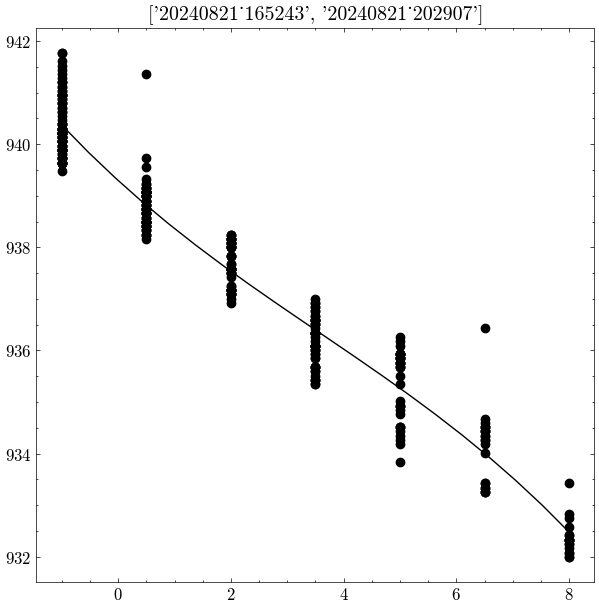

20240822142936
942.9085083007812


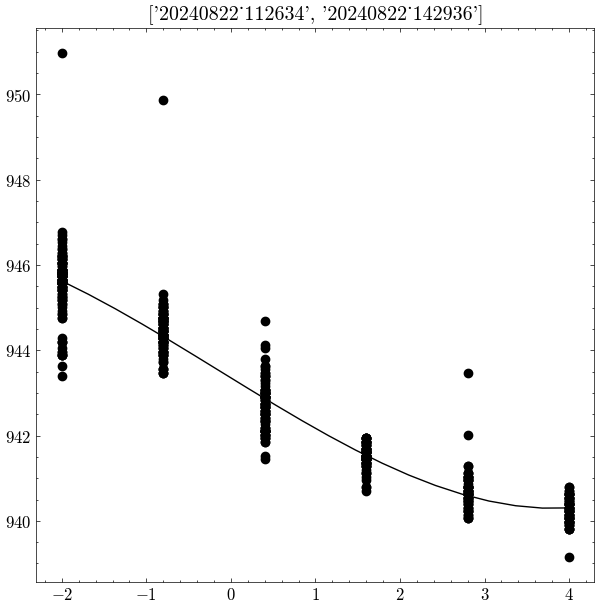

20240823002423
949.7119750976562


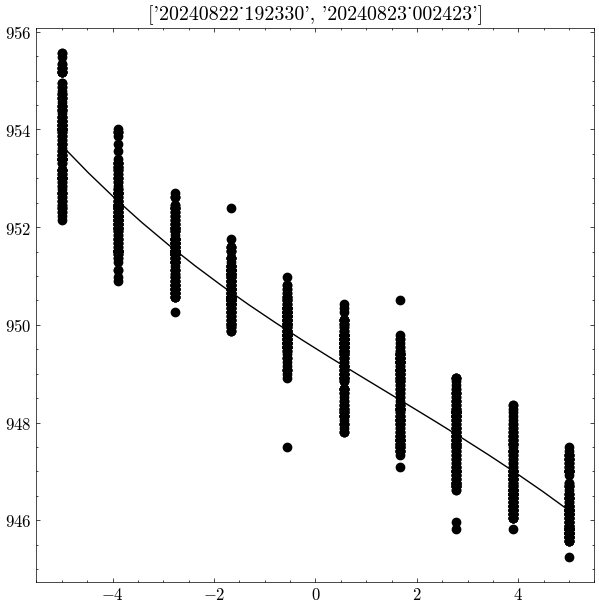

20240823135531
955.0262451171875


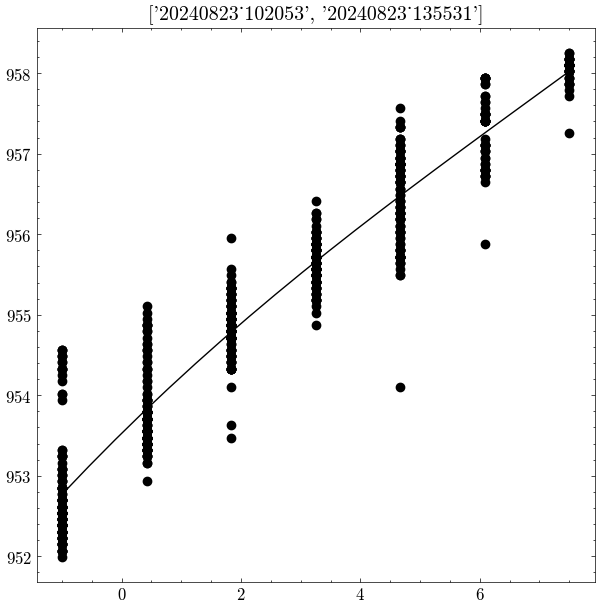

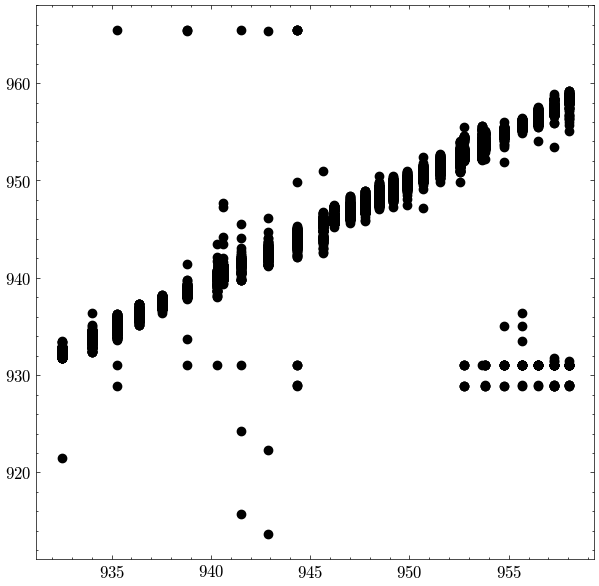

In [115]:


# Fit PCA values to cavity length
if 'pca' not in data.keys():
    print('!')
    png_data = power_length_analysis.data_dict(files)
    data.update({'pca': png_data['pca']})

pca_length = []

for i in t_chunks:
    # Creates mask for stimulated emission and each time cavity is locked
    mint = int(i[0].split('_')[0] + i[0].split('_')[1])
    maxt = int(i[1].split('_')[0] + i[1].split('_')[1])
    print(maxt)
    tmask = (mint <= data['t']) & (data['t'] <= maxt)
    mask = tmask & stim_mask

    # plt.scatter(data['cavity_length'][mask], data['power'][mask])
    # plt.show()
    
    # removes any outlying points
    mean_length = np.median(data['cavity_length'][mask])
    print(mean_length)
    length_mask = (mean_length - 10 <= data['cavity_length']) & (data['cavity_length'] <= mean_length + 10)
    mask = tmask & stim_mask & length_mask

    plt.scatter(data['pca'][mask], data['cavity_length'][mask])
    # plt.show()
    # fits pca values to cavity length
    _, fit = power_length_analysis.fit_pca(data['cavity_length'][mask], data['pca'][mask])
    pca_length += list(fit(data['pca'][tmask]))

    x = np.linspace(min(data['pca'][mask]), max(data['pca'][mask]), 20)
    plt.plot(x, fit(x))
    plt.title(i)
    plt.show()

data.update({'pca_length': np.array(pca_length)})

plt.scatter(data['pca_length'], data['cavity_length'])
plt.show()

# Choose Displacement

(Only use if applicable)

In [127]:
import dill
#Choose displacement
print(np.unique(data['position']))
positions = np.unique(data['position'])

if socket.gethostname() == 'Louis_PC':
    disp_path = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\displacement_func.dill'

with open(disp_path, 'rb') as f:
    disp_func = dill.load(f)

dataset = 3

displacements = np.array(disp_func(positions))
displacements = displacements - min(displacements)
print(displacements)
pos_mask = select_files.select_position(data, positions[dataset])

#combine the masks
stim_pos_mask = stim_mask & pos_mask
thermal_mask = pos_mask & (~stim_mask)
print(np.sum(mask))


[      0  571428 1142857 1714285 2285714 2857142 3428571 4000000]
[ 0.          1.8917039   3.78341111  5.67511501  7.56682222  9.45852611
 11.35023332 13.24194053]
692


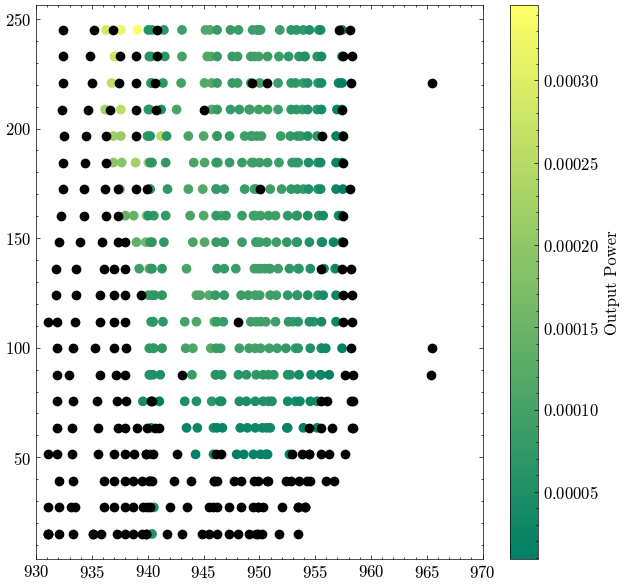

In [128]:

fig, ax = plt.subplots(1, 1)
# Thermal cloud histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][~stim_mask],
#     data['power'][~stim_mask],
#     [910,970], [0,120],
#     'grey', 30, fig = fig, ax = ax, alpha = 1
# )

# # Stimulated emission histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][stim_mask],
#     data['power'][stim_mask],
#     [910,970], [0,120],
#     'orchid', 30, fig = fig, ax = ax, alpha= 1
# )

# print(data['pca_length'][stim_mask])

# Scattered points



scat = ax.scatter(data['cavity_length'][stim_pos_mask], data['power'][stim_pos_mask], c=data['meter_reading'][stim_pos_mask],
                  cmap='summer', label='Above Threshold')
ax.scatter(data['cavity_length'][thermal_mask], data['power'][thermal_mask], color='black', label='Below Threshold')
ax.set_xlim([930, 970])
cbar = fig.colorbar(scat, ax=ax, label='Output Power')
plt.show()



# Interactive Plot
Colours are random

In [118]:
#
#power_length_analysis.interactive_scatter(data['cavity_length'], data['power'], data['file'], labels_data = np.random.randint(0, 5, size=(len(data['pca_length'][stim_mask]))))

labels = np.ones(len(data['power']))
labels[stim_mask] = 0
labels[-1] = 2

#If only showing stim mask:
labels = np.random.randint(0, 5, len(data['power']))

power_length_analysis.interactive_scatter(data['cavity_length'][mask], data['power'][mask], data['file'][mask], labels_data=labels[mask])

# Binned plot
Use this to test out the best bin count. This uses the physt module, and tries to make bins with the same number of points per bin. Don't increase the bin count too much.


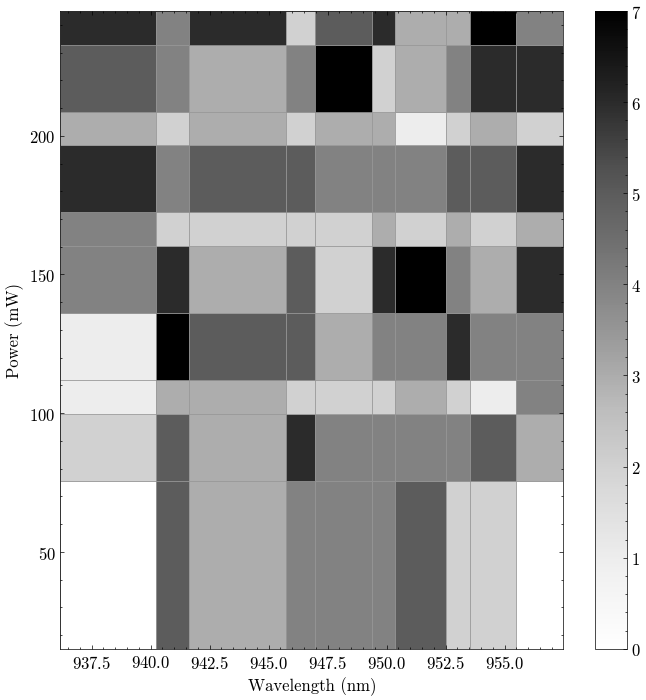

In [129]:
from physt import h2
bin_count = [10, 10]

histogram = h2(data['cavity_length'][stim_pos_mask], data['power'][stim_pos_mask], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
histogram.plot()
bins = histogram.numpy_bins #Get bins to use in numpy - Use later!


#More accurate binning when including data under threshold - may break if pca length isn't very good though
# histogram = h2(data['cavity_length'], data['power'], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
# histogram.plot()
# bins = histogram.numpy_bins #Get bins to use in numpy - Use later!

# Basic Clustering

Kmeans

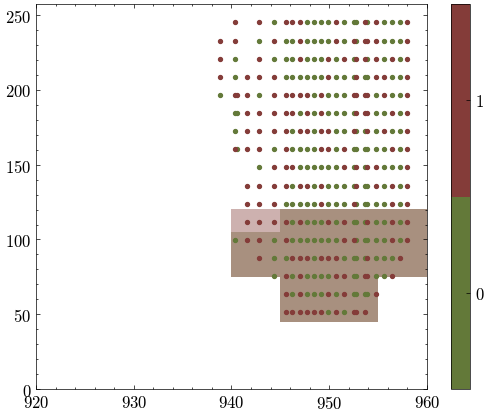

In [93]:
# Kmeans clustering on images
cluster_labels, _ = Meta_classifier.Kmeans_no_CNN(data['file'][stim_pos_mask], 2)

# Plots each cluster
fig, ax, _, _ = power_length_analysis.all_cluster_plot(
    np.amax(cluster_labels), cluster_labels,
    data['pca_length'][stim_pos_mask], data['power'][stim_pos_mask],
    'tab20b', 8, [920, 960], [0, 120], 8
)



Fuzzy CMeans

In [121]:
fuzzy_label, alpha, mem_mat = Meta_classifier.quick_fcmeans(data['flat_image'][stim_pos_mask], 2, 1.5, return_matrix=True)

C:\Users\Pouis\AppData\Local\Temp\ipykernel_4648\1594798083.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


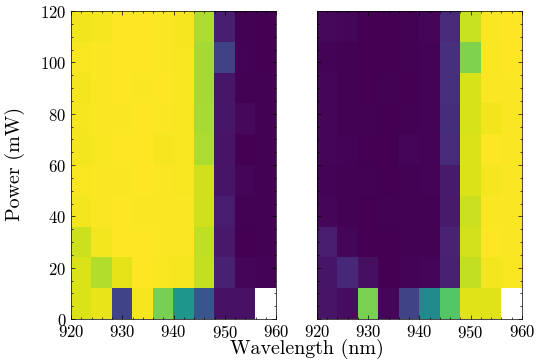

In [122]:
#num plots, num columns, num rows
fig, axes, gs = power_length_analysis.grid_plot(2, 2, 1, 0.5, 0.5)

for i, col in enumerate(mem_mat):
    # power_length_analysis.plot_2dhist(
    #     data['pca_length'][~stim_mask],
    #     data['power'][~stim_mask],
    #     [920, 960], [0, 240],
    #     'grey', 15, fig=fig, ax=axes[i], alpha=1
    # )

    power_length_analysis.plot_2d_stat_hist(
        data['pca_length'][stim_pos_mask],
        data['power'][stim_pos_mask],
        col,
        [920, 960], [0, 120], bins=bins,
        cmap='viridis', fig=fig, ax=axes[i], facecolor='darkgrey'
    )

fig.supxlabel('Wavelength (nm)')
fig.supylabel('Power (mW)')
plt.tight_layout()
plt.show()

In [ ]:
fuzzy_label[-1] = -1
power_length_analysis.interactive_scatter(data['pca_length'][stim_pos_mask], data['power'][stim_pos_mask],
                                          data['file'][stim_pos_mask], labels_data=fuzzy_label)

# CNN

Make Predictions

In [130]:
if socket.gethostname() == 'Louis_PC':
    model_root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\220824_conf_'
    save_path = model_root + 'predictions'
# %matplotlib qt
with open(model_root + 'model_parameters.json', 'r') as f:
    model_params = json.load(f)

phases = len(model_params['training args']['modes'])

In [131]:
feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_pos_mask], root = model_root, phases = 4, sigm=[0.1,0.1])
outputs, preds = Meta_classifier.predict_full_output(data['file'][stim_pos_mask], root = model_root, phases = 4, sigm= [0.1,0.1])

conf_outs = {
    'feature_vectors': feat_vectors.tolist(),
    'outputs': outputs.tolist(),
    'predictions': preds.tolist()
}

with open(save_path + f'_{displacements[dataset]:.2f}.json', 'w') as f:
    json.dump(conf_outs,f)

0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
368it [09:10,  1.50s/it]
0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
368it [06:49,  1.11s/it]


In [132]:
conf_outs.update({
    'feature_vectors': np.array(conf_outs['feature_vectors']),
    'outputs': np.array(conf_outs['outputs']),
    'predictions': np.array(conf_outs['predictions'])
    })

Confidence plot

0


Text(0.5, 0.98, 'Displacement: 5.68 $\\mu m$')

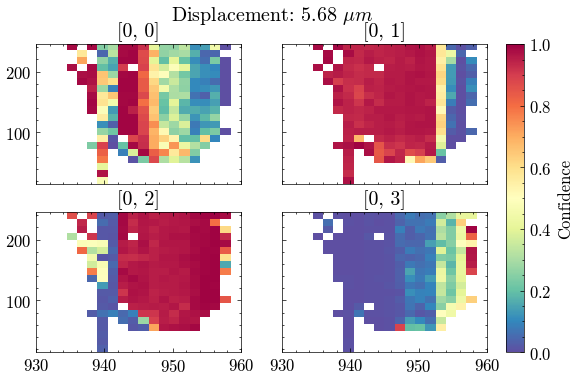

In [151]:
#Scale for all colorbars
vs = [np.min(conf_outs['outputs']), np.max(conf_outs['outputs'])]

fig, axes, gs = power_length_analysis.grid_plot(
    nplots=phases, ncols=2, nrows=2,
    wspace=0.2, hspace=0.2)

for i in range(conf_outs['outputs'].shape[1]):
    mode_conf = conf_outs['outputs'][:, i, 0]
    _, _, plot, stat = power_length_analysis.plot_2d_stat_hist(data['pca_length'][stim_pos_mask],
                                                               data['power'][stim_pos_mask],
                                                               mode_conf, [930, 960],
                                                               [min(data['power']), max(data['power'])], bins=20,
                                                               cmap='Spectral_r',
                                                               fig=fig, ax=axes[i], vs=vs, ret_stat=True)
    
    axes[i].set_title(model_params['training args']['modes'][i]['mode'])

print(np.min(preds))

cbax = plt.subplot(gs[1])
plt.colorbar(plot, cbax, cmap='Spectral_r', label='Confidence', )

fig.suptitle(f'Displacement: {displacements[dataset]:.2f} $\mu m$')


# MULTIRUN!

Grid plot - threshold not threshold

In [134]:
from math import ceil
nplots = len(positions)
nrows = 2
ncols = ceil(nplots / nrows)

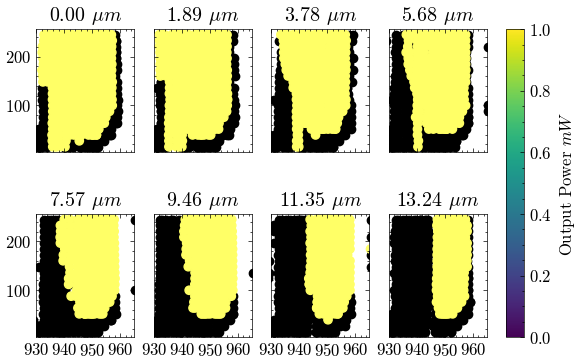

In [153]:
fig, axes, gs = power_length_analysis.grid_plot(nplots, ncols, nrows, wspace=0.5, hspace=0.5)

vs = [np.amin(data['meter_reading'][stim_mask]), np.amax(data['meter_reading'][stim_mask])]

cmap = 'summer'

for i, (disp, pos) in enumerate(zip(displacements, positions)):
    # create mask for dataset
    pos_mask = select_files.select_position(data, pos)
    thermal_mask = pos_mask & (~stim_mask)
    sp_mask = pos_mask & stim_mask

    scat = axes[i].scatter(data['cavity_length'][thermal_mask], data['power'][thermal_mask], color='black', label='Below Threshold')

    axes[i].scatter(data['cavity_length'][sp_mask], data['power'][sp_mask], c=data['meter_reading'][sp_mask]*1e3,
                  cmap=cmap, label='Above Threshold', vmin = vs[0], vmax = vs[1])
    
    axes[i].set_xlim([930,965])

    axes[i].set_title(f'{disp:.2f} $\mu m$')

cbax = plt.subplot(gs[1])
plt.colorbar(scat, cbax, cmap = cmap, label = "Output Power $mW$")

plt.show()
    



Predict entire dataset with BEC not BEC model (will take a while)

In [135]:
if socket.gethostname() == 'Louis_PC':
    model_root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\220824_multi_'
    save_path = model_root + 'predictions'

In [136]:
feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_mask], root = model_root, phases = 1, sigm=[0.1,0.1])
outputs, preds = Meta_classifier.predict_full_output(data['file'][stim_mask], root = model_root, phases = 1, sigm= [0.1,0.1])

cnn_outs = {
    'feature_vectors': feat_vectors.tolist(),
    'outputs': outputs.tolist(),
    'predictions': preds.tolist()
}

# to be loaded later 
with open(save_path, 'w') as f:
    json.dump(cnn_outs,f)

0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
2888it [05:12,  9.23it/s]
0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
2888it [05:01,  9.58it/s]


In [142]:
# with open(save_path, 'r') as f:
#     cnn_outs = json.load(f)

for i, (key, val) in enumerate(zip(cnn_outs.keys(), cnn_outs.values())):
    cnn_outs.update({key: np.array(val)})

BEC not BEC plot

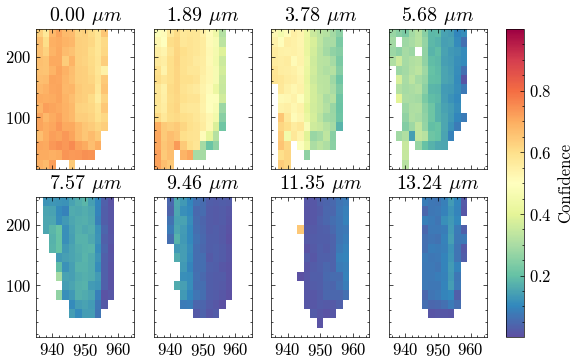

In [152]:
from physt import h2
bin_count = [10, 10]
cmap = 'Spectral_r'
vs = [np.min(cnn_outs['outputs']), np.max(cnn_outs['outputs'])]

fig, axes, gs = power_length_analysis.grid_plot(
    nplots=nplots, ncols=ncols, nrows=nrows,
    wspace=0.2, hspace=0.2)

stim_data = {}

for k,v in zip(data.keys(), data.values()):
    stim_data.update({k: v[stim_mask]})


for i, (disp, pos) in enumerate(zip(displacements, positions)):
    pos_mask = select_files.select_position(stim_data, pos)

    histogram = h2(stim_data['cavity_length'][pos_mask], stim_data['power'][pos_mask], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
    bins = histogram.numpy_bins

    conf = cnn_outs['outputs'][:, 0, 0][pos_mask]
    _, _, plot, stat = power_length_analysis.plot_2d_stat_hist(stim_data['pca_length'][pos_mask],
                                                               stim_data['power'][pos_mask],
                                                               conf, [935, 965],
                                                               [min(data['power']), max(data['power'])], bins=15,
                                                               cmap=cmap,
                                                               fig=fig, ax=axes[i], vs=vs, ret_stat=True)
    
    axes[i].set_title(f'{disp:.2f} $\mu m$')


cbax = plt.subplot(gs[1])
plt.colorbar(plot, cbax, cmap=cmap, label='Confidence', )
plt.show()
